# GWTC Population Sampling

In [1]:
import warnings
warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')

import numpy as np
import matplotlib.pyplot as plt
from gwGenealogy.binaries import sample_gwtc_population, available_catalogs
from gwGenealogy.utils import set_rcparams, compute_jensen_shannon_divergence

set_rcparams()

lal.MSUN_SI != Msun


## Available catalogs

In [2]:
available_catalogs()

['gwtc5', 'gwtc5_var4', 'gwtc5_madau_dickinson', 'gwtc4', 'gwtc3']

## Sample from GWTC-5 default model

In [3]:
pop = sample_gwtc_population(n_samples=50000, catalog='gwtc5', source='posterior', seed=42)
print(f"Keys: {list(pop.keys())}")
print(f"Number of samples: {len(pop['mass_1'])}")

Keys: ['mass_1', 'mass_2', 'q', 'small_q', 'a1', 'a2', 'cos_theta1', 'cos_theta2', 'theta1', 'theta2', 'redshift', 'chi_eff', 'chi_p', 'hyper_draw_index']
Number of samples: 50000


## Mass and spin distributions

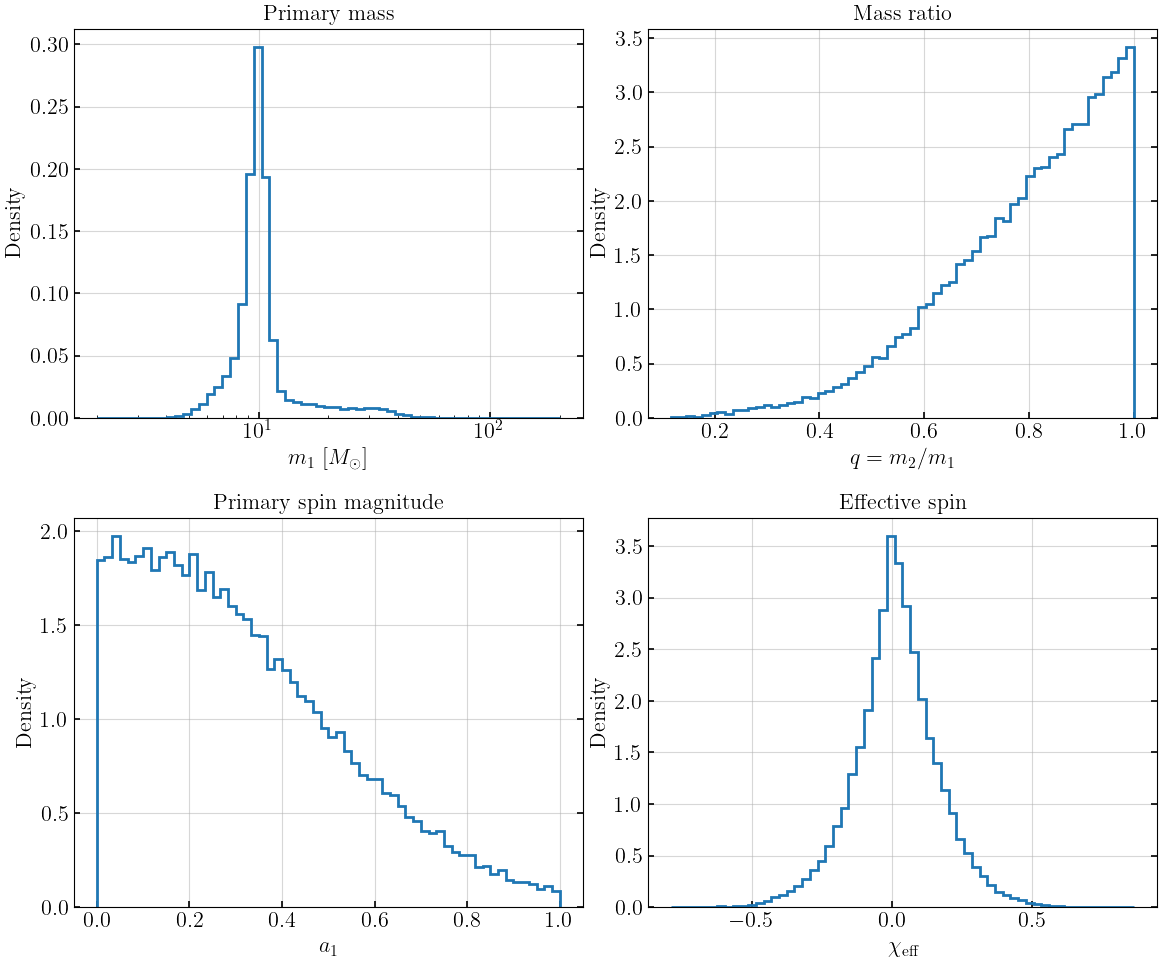

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(pop['mass_1'], bins=np.logspace(np.log10(2), np.log10(200), 60), density=True, histtype='step', lw=2)
axes[0, 0].set_xlabel(r'$m_1$ [$M_\odot$]')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_xscale('log')
axes[0, 0].set_title('Primary mass')

axes[0, 1].hist(pop['small_q'], bins=60, density=True, histtype='step', lw=2)
axes[0, 1].set_xlabel(r'$q = m_2/m_1$')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Mass ratio')

axes[1, 0].hist(pop['a1'], bins=60, density=True, histtype='step', lw=2)
axes[1, 0].set_xlabel(r'$a_1$')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Primary spin magnitude')

axes[1, 1].hist(pop['chi_eff'], bins=60, density=True, histtype='step', lw=2)
axes[1, 1].set_xlabel(r'$\chi_{\rm eff}$')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Effective spin')

plt.tight_layout()
plt.show()

## GWTC-3 vs GWTC-5 comparison

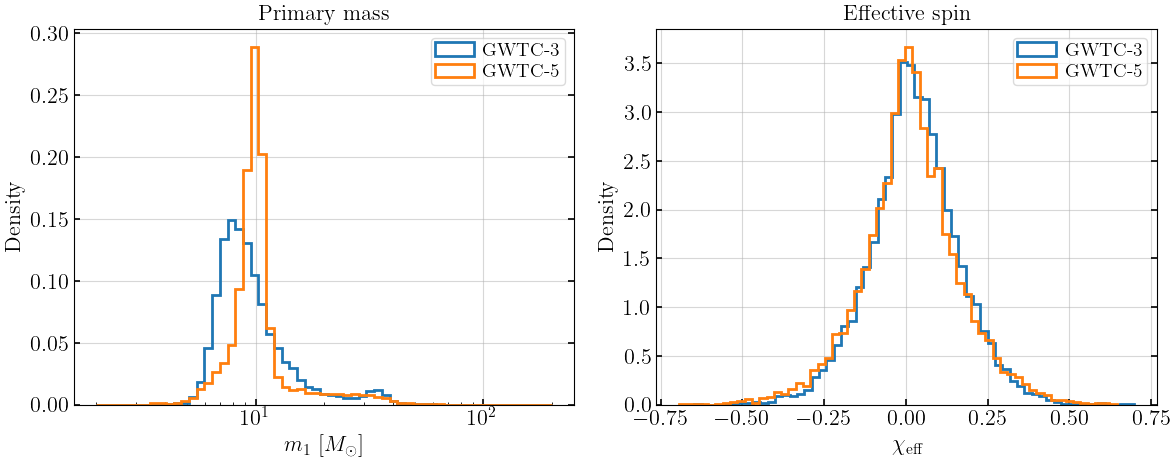

JSD(m1):      0.065258
JSD(chi_eff): 0.004499


In [5]:
pop_gwtc3 = sample_gwtc_population(n_samples=10000, catalog='gwtc3', source='posterior', seed=100)
pop_gwtc5 = sample_gwtc_population(n_samples=10000, catalog='gwtc5', source='posterior', seed=101)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(pop_gwtc3['mass_1'], bins=np.logspace(np.log10(2), np.log10(200), 60), density=True, histtype='step', lw=2, label='GWTC-3')
axes[0].hist(pop_gwtc5['mass_1'], bins=np.logspace(np.log10(2), np.log10(200), 60), density=True, histtype='step', lw=2, label='GWTC-5')
axes[0].set_xscale('log')
axes[0].set_xlabel(r'$m_1$ [$M_\odot$]')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_title('Primary mass')

axes[1].hist(pop_gwtc3['chi_eff'], bins=60, density=True, histtype='step', lw=2, label='GWTC-3')
axes[1].hist(pop_gwtc5['chi_eff'], bins=60, density=True, histtype='step', lw=2, label='GWTC-5')
axes[1].set_xlabel(r'$\chi_{\rm eff}$')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].set_title('Effective spin')

plt.tight_layout()
plt.show()

jsd_m1 = compute_jensen_shannon_divergence(pop_gwtc3['mass_1'], pop_gwtc5['mass_1'])
jsd_chi = compute_jensen_shannon_divergence(pop_gwtc3['chi_eff'], pop_gwtc5['chi_eff'])
print(f"JSD(m1):      {jsd_m1:.6f}")
print(f"JSD(chi_eff): {jsd_chi:.6f}")

## Posterior vs prior predictive

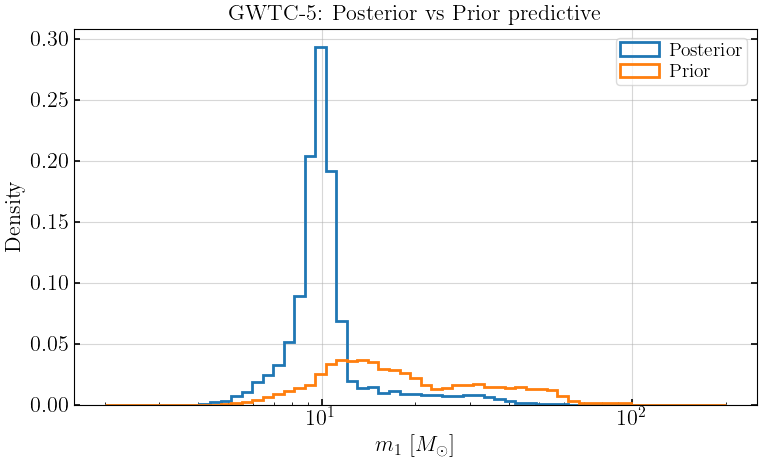

JSD(m1, posterior vs prior): 0.243331


In [6]:
pop_posterior = sample_gwtc_population(n_samples=10000, catalog='gwtc5', source='posterior', seed=200)
pop_prior = sample_gwtc_population(n_samples=10000, catalog='gwtc5', source='prior', seed=201)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pop_posterior['mass_1'], bins=np.logspace(np.log10(2), np.log10(200), 60), density=True, histtype='step', lw=2, label='Posterior')
ax.hist(pop_prior['mass_1'], bins=np.logspace(np.log10(2), np.log10(200), 60), density=True, histtype='step', lw=2, label='Prior')
ax.set_xscale('log')
ax.set_xlabel(r'$m_1$ [$M_\odot$]')
ax.set_ylabel('Density')
ax.legend()
ax.set_title('GWTC-5: Posterior vs Prior predictive')
plt.tight_layout()
plt.show()

jsd_m1_pp = compute_jensen_shannon_divergence(pop_posterior['mass_1'], pop_prior['mass_1'])
print(f"JSD(m1, posterior vs prior): {jsd_m1_pp:.6f}")

## Redshift distribution

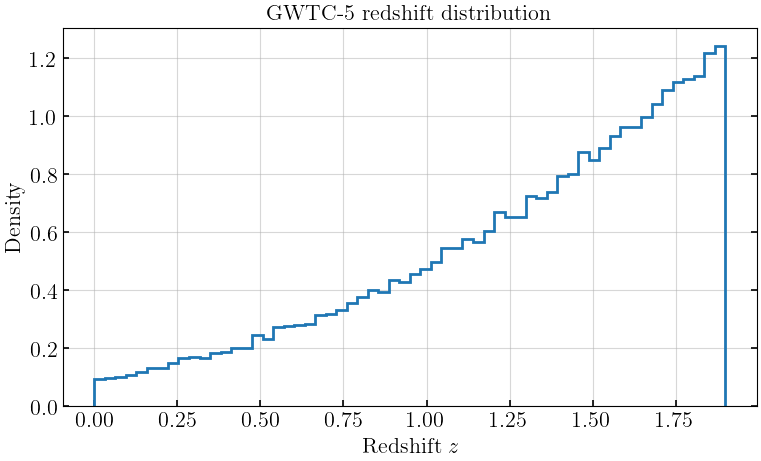

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pop['redshift'], bins=60, density=True, histtype='step', lw=2)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel('Density')
ax.set_title('GWTC-5 redshift distribution')
plt.tight_layout()
plt.show()